In [1]:
# Import libraries for data handling and visualization

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Load the raw player dataset

df = pd.read_csv("../data/raw/players_data_light-2025_2026.csv")

df.head()

,Rk,Player,Nation,Pos,Squad,Comp,Age,Born,MP,Starts,...,Save%,W,D,L,CS,CS%,PKatt_stats_keeper,PKA,PKsv,PKm
0,1,Brenden Aaronson,us USA,"MF,FW",Leeds United,eng Premier League,25.0,2000.0,34,27,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,Zach Abbott,eng ENG,DF,Nottingham Forest,eng Premier League,19.0,2006.0,3,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,Jones El-Abdellaoui,ma MAR,"MF,FW",Celta Vigo,es La Liga,20.0,2006.0,21,4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,Himad Abdelli,dz ALG,MF,Marseille,fr Ligue 1,26.0,1999.0,8,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,Himad Abdelli,dz ALG,MF,Angers,fr Ligue 1,26.0,1999.0,13,11,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
# Define Champions League teams and create UCL flag

ucl_teams = [
    "Arsenal", "Athletic Club", "Atlético Madrid", "Atalanta",
    "Barcelona", "Bayern Munich", "Chelsea", "Dortmund",
    "Eintracht Frankfurt", "Inter", "Juventus", "Leverkusen",
    "Liverpool", "Manchester City", "Marseille", "Monaco",
    "Napoli", "Newcastle United", "Paris Saint-Germain",
    "Real Madrid", "Tottenham Hotspur", "Villarreal"
]

df["is_ucl_team"] = df["Squad"].isin(ucl_teams)

In [4]:
# Filter strikers and create per90 attacking metrics

df = df[(df["MP"] >= 15) & (df["Min"] >= 900)].copy()

strikers = df[df["Pos"] == "FW"].copy()

striker_data = strikers[
    ["Player", "Squad", "Comp", "MP", "Min", "90s", "is_ucl_team",
     "Gls", "Ast", "G+A", "Sh", "SoT", "G/Sh"]
].copy()

striker_data["Gls_per90"] = striker_data["Gls"] / striker_data["90s"]
striker_data["Ast_per90"] = striker_data["Ast"] / striker_data["90s"]
striker_data["Sh_per90"] = striker_data["Sh"] / striker_data["90s"]
striker_data["SoT_per90"] = striker_data["SoT"] / striker_data["90s"]

striker_data.head()

,Player,Squad,Comp,MP,Min,90s,is_ucl_team,Gls,Ast,G+A,Sh,SoT,G/Sh,Gls_per90,Ast_per90,Sh_per90,SoT_per90
19,Ragnar Ache,Köln,de Bundesliga,29,1718,19.1,False,7,4,11,52,22,0.13,0.366492,0.209424,2.722513,1.151832
21,Akor Adams,Sevilla,es La Liga,28,1846,20.5,False,8,3,11,55,27,0.09,0.390244,0.146341,2.682927,1.317073
22,Che Adams,Torino,it Serie A,31,1826,20.3,False,5,2,7,48,14,0.10,0.246305,0.098522,2.364532,0.689655
58,Ludovic Ajorque,Brest,fr Ligue 1,29,2550,28.3,False,7,9,16,47,15,0.15,0.247350,0.318021,1.660777,0.530035
75,Alexandre Alemão,Rayo Vallecano,es La Liga,22,969,10.8,False,2,0,2,19,9,0.11,0.185185,0.000000,1.759259,0.833333


In [5]:
# Define radar chart features

radar_features = [
    "Gls_per90",
    "Ast_per90",
    "Sh_per90",
    "SoT_per90",
    "G/Sh"
]

In [6]:
# Select players for comparison

player_1_name = "Julián Álvarez"
player_2_name = "Ragnar Ache"

player_1 = striker_data[
    striker_data["Player"] == player_1_name
]

player_2 = striker_data[
    striker_data["Player"] == player_2_name
]

In [7]:
# Extract radar values

values_1 = player_1[radar_features].values.flatten().tolist()
values_2 = player_2[radar_features].values.flatten().tolist()

# Close radar chart loop
values_1 += values_1[:1]
values_2 += values_2[:1]

angles = np.linspace(
    0,
    2 * np.pi,
    len(radar_features),
    endpoint=False
).tolist()

angles += angles[:1]

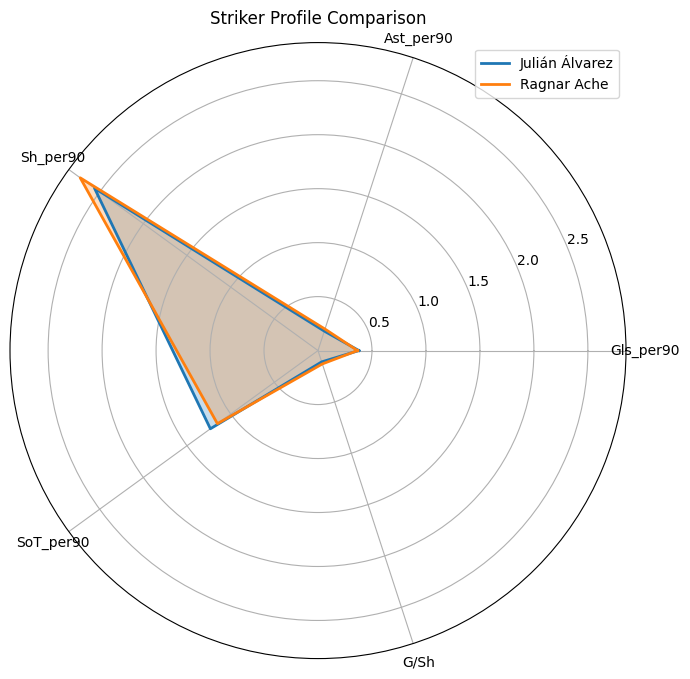

In [8]:
# Create radar chart

fig, ax = plt.subplots(
    figsize=(8, 8),
    subplot_kw=dict(polar=True)
)

# Julián Álvarez
ax.plot(
    angles,
    values_1,
    linewidth=2,
    label=player_1_name
)

ax.fill(
    angles,
    values_1,
    alpha=0.25
)

# Ragnar Ache
ax.plot(
    angles,
    values_2,
    linewidth=2,
    label=player_2_name
)

ax.fill(
    angles,
    values_2,
    alpha=0.25
)

# Labels
ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_features)

# Title
plt.title("Striker Profile Comparison")

# Legend
plt.legend(loc="upper right")

plt.show()

In [9]:
# Save radar chart

import os

os.makedirs("../images", exist_ok=True)

fig.savefig(
    "../images/julian_alvarez_vs_ragnar_ache_radar.png",
    bbox_inches="tight"
)

In [10]:
def compare_players(player_a, player_b):

    comparison_features = [
        "Gls_per90",
        "Ast_per90",
        "Sh_per90",
        "SoT_per90",
        "G/Sh"
    ]

    player1 = striker_data[
        striker_data["Player"] == player_a
    ]

    player2 = striker_data[
        striker_data["Player"] == player_b
    ]

    comparison = pd.DataFrame({
        "Metric": comparison_features,
        player_a: player1[comparison_features].values.flatten(),
        player_b: player2[comparison_features].values.flatten()
    })

    return comparison

In [11]:
compare_players(
    "Julián Álvarez",
    "Ragnar Ache"
)

,Metric,Julián Álvarez,Ragnar Ache
0,Gls_per90,0.379147,0.366492
1,Ast_per90,0.189573,0.209424
2,Sh_per90,2.559242,2.722513
3,SoT_per90,1.232227,1.151832
4,G/Sh,0.110000,0.130000


In [12]:
comparison_table = compare_players(
    "Julián Álvarez",
    "Ragnar Ache"
)

comparison_table.to_csv(
    "../data/processed/julian_alvarez_vs_ragnar_ache_comparison.csv",
    index=False
)

comparison_table

,Metric,Julián Álvarez,Ragnar Ache
0,Gls_per90,0.379147,0.366492
1,Ast_per90,0.189573,0.209424
2,Sh_per90,2.559242,2.722513
3,SoT_per90,1.232227,1.151832
4,G/Sh,0.110000,0.130000
